<a href="https://colab.research.google.com/github/hudamohmand/Project_3_Demand_Estimation/blob/main/demand_estimation_data_analyst.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Demand Estimation and Market Analysis: Air Fryers

In this lab, you will study the market for air fryers using brand-year data aggregated from Amazon purchases. The goal is to move from descriptive analysis to a simple demand model, and then use that model to infer markups and unit costs.

Use the cleaned file:

```python
air_fryers_clean_brand_year.csv
```

This file keeps the top 10 air-fryer brands from 2019-2023 and drops the long tail of very small brands. The variable `brand_share` has already been recomputed within this cleaned name-brand market, so shares sum to 1 within each year.

## Data

Each row is one brand in one year.

Important columns:

- `year`: calendar year
- `brand`: air-fryer brand
- `purchase_count`: number of purchases by that brand in that year
- `product_count`: number of distinct products observed for that brand-year
- `avg_price`: average price for that brand-year
- `avg_rating`: average review rating for that brand-year
- `brand_share`: purchase share within the cleaned air-fryer market in that year
- `log_brand_share`: `np.log(brand_share)`, already computed for convenience
- `compact_share`, `dual_basket_share`, `oven_style_share`, `rotisserie_share`, `window_share`: product characteristic shares for the brand-year

The original lecture wrote the demand equation using an outside option:

$$
\log(s_{bt}) - \log(s_{ot}).
$$

For this cleaned dataset, we dropped the nuisance long-tail brands instead of treating them as an outside option. You should therefore use:

$$
y_{bt} = \log(s_{bt})
$$

as the outcome and include **year dummies**. The year dummies absorb the year-specific denominator of the multinomial logit share equation. This keeps the assignment focused on the cleaned name-brand market.

## 1. Data Analysis

Load `air_fryers_clean_brand_year.csv`.

1. Verify that the data contain 10 brands and the years 2019-2023.
2. Plot the following over time by brand:
   - average price
   - average rating
   - brand market share
3. Summarize the product characteristics:
   - Which features are common?
   - Which features are rare?
   - Are there brands that seem to specialize in different product types?
4. Write a short paragraph describing the market. Which brands are expensive? Which brands have large shares? Does the market look stable over time?

This part of the work is the **data analyst** role: making the data trustworthy, visual, and interpretable before building a model.

In [ ]:
#1 Load Data and verify
import pandas as pd

df = pd.read_csv('air_fryers_clean_brand_year.csv')
print(df.head())

brands = df['brand'].unique()
years = df['year'].unique()

print("Brands:", brands)
print("Number of brands:", len(brands))

print("Years:", sorted(years))

     category  year       brand  purchase_count  product_count   avg_price  \
0  air_fryers  2019     chefman            1146             10   72.963695   
1  air_fryers  2019      cosori              11              2  159.990000   
2  air_fryers  2019   cuisinart            1616             22  229.465274   
3  air_fryers  2019        dash            3011             19   55.176333   
4  air_fryers  2019  gowise usa            4405             45   83.575551   

   avg_rating  compact_share  dual_basket_share  oven_style_share  \
0    4.434119       1.000000                0.0          0.780977   
1    4.581818       1.000000                0.0          0.090909   
2    4.481312       0.993812                0.0          0.889851   
3    4.390767       1.000000                0.0          0.973431   
4    4.552259       0.999773                0.0          0.129398   

   rotisserie_share  window_share  market_purchases  brand_share  \
0          0.243455      0.184119             15

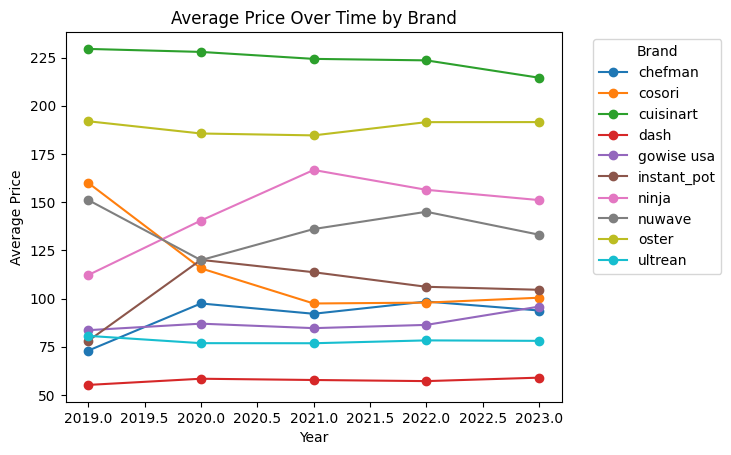

In [ ]:
#2 Plot average price
import matplotlib.pyplot as plt

price_trend = df.pivot(index='year', columns='brand', values='avg_price')

price_trend.plot(marker='o')
plt.title("Average Price Over Time by Brand")
plt.xlabel("Year")
plt.ylabel("Average Price")
plt.legend(title="Brand", bbox_to_anchor=(1.05, 1))
plt.show()

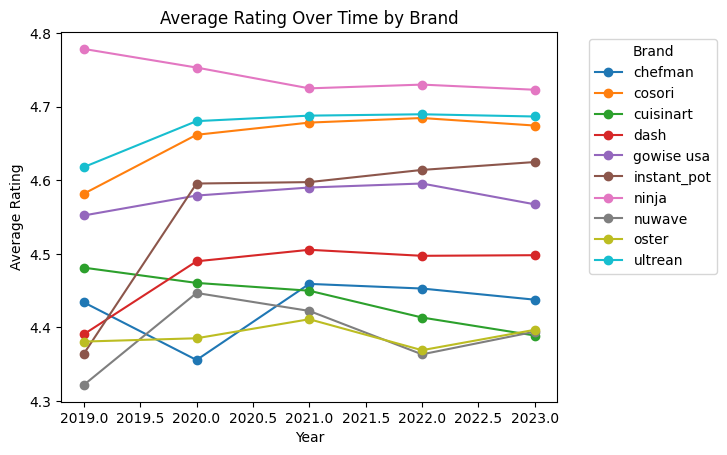

In [ ]:
#Plot average rating
rating_trend = df.pivot(index='year', columns='brand', values='avg_rating')

rating_trend.plot(marker='o')
plt.title("Average Rating Over Time by Brand")
plt.xlabel("Year")
plt.ylabel("Average Rating")
plt.legend(title="Brand", bbox_to_anchor=(1.05, 1))
plt.show()

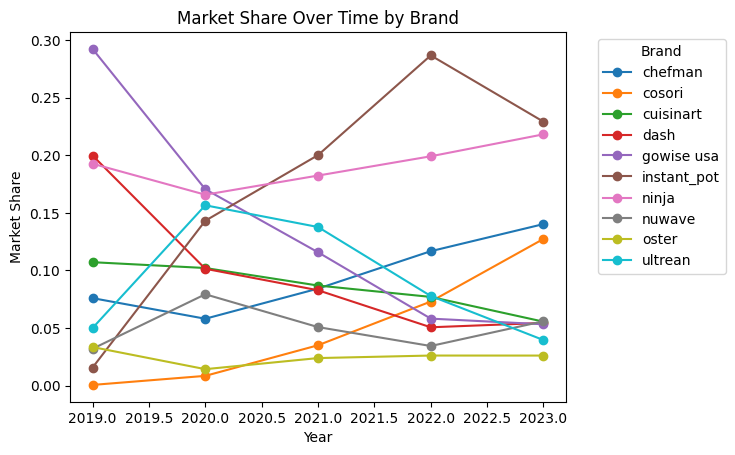

In [ ]:
#Plot market share
market_share = df.pivot(index='year', columns='brand', values='brand_share')

market_share.plot(marker='o')
plt.title("Market Share Over Time by Brand")
plt.xlabel("Year")
plt.ylabel("Market Share")
plt.legend(title="Brand", bbox_to_anchor=(1.05, 1))
plt.show()

In [ ]:
#3 Product Characteristics
feature_cols = [
    'compact_share',
    'dual_basket_share',
    'oven_style_share',
    'rotisserie_share',
    'window_share'
]

df[feature_cols].mean().sort_values(ascending=False)

df.groupby('brand')[feature_cols].mean()

,compact_share,dual_basket_share,oven_style_share,rotisserie_share,window_share
brand,,,,,
chefman,0.961595,0.013462,0.596962,0.370490,0.363081
cosori,0.996784,0.000000,0.029952,0.024076,0.000000
cuisinart,0.995902,0.000000,0.913059,0.000000,0.000000
dash,0.999481,0.000000,0.890098,0.000000,0.000000
gowise usa,0.999877,0.000000,0.183790,0.183569,0.001320
instant_pot,0.859655,0.000030,0.674784,0.102362,0.003012
ninja,0.992084,0.002488,0.100477,0.000000,0.000000
nuwave,0.995431,0.006622,0.542646,0.027123,0.000000
oster,1.000000,0.000000,0.864518,0.000000,0.000000


In [ ]:
#Common vs Rare Reatures
feature_cols = [
    'compact_share',
    'dual_basket_share',
    'oven_style_share',
    'rotisserie_share',
    'window_share'
]

feature_freq = df[feature_cols].mean().sort_values(ascending=False)

print("Most Common Features:\n", feature_freq.head())
print("\nMost Rare Features:\n", feature_freq.tail())

Most Common Features:
 compact_share        0.980081
oven_style_share     0.562647
rotisserie_share     0.070762
window_share         0.036741
dual_basket_share    0.002260
dtype: float64

Most Rare Features:
 compact_share        0.980081
oven_style_share     0.562647
rotisserie_share     0.070762
window_share         0.036741
dual_basket_share    0.002260
dtype: float64


Which features are common?
**Answer**: The most commom features is compact_share which is about 0.98. Another moderately common feature is oven_style_share which equals 0.56.

Which features are rare?
**Answer** Features that are rare is the window_share (0.036) and dual_basket_share(0.002).



In [ ]:
#Brand Specialization
brand_features = df.groupby('brand')[feature_cols].mean()

print(brand_features)

             compact_share  dual_basket_share  oven_style_share  \
brand                                                             
chefman           0.961595           0.013462          0.596962   
cosori            0.996784           0.000000          0.029952   
cuisinart         0.995902           0.000000          0.913059   
dash              0.999481           0.000000          0.890098   
gowise usa        0.999877           0.000000          0.183790   
instant_pot       0.859655           0.000030          0.674784   
ninja             0.992084           0.002488          0.100477   
nuwave            0.995431           0.006622          0.542646   
oster             1.000000           0.000000          0.864518   
ultrean           1.000000           0.000000          0.830181   

             rotisserie_share  window_share  
brand                                        
chefman              0.370490      0.363081  
cosori               0.024076      0.000000  
cuisinart  

Are there brands that seem to specialize in different product types?

**Answer** Yes, some brands seem to specialize in different types of air fryers. Almost all brands mainly sell compact models, but they differ in other features. For example, Cuisinart, Dash, Oster, and Ultrean have high oven-style shares, so they focus more on larger, multifunctional air fryers. On the other hand, Cosori and Ninja have very low oven-style shares, meaning they mostly sell simpler basket-style models. Chefman stands out because it has the highest rotisserie and window shares, which suggests it focuses more on feature-heavy products. GoWise USA and Instant Pot also include some extra features, but not as much. Overall, this shows that brands try to stand out by either offering simple, basic designs or more advanced air fryers with extra features.

####4. Write a short paragraph describing the market. Which brands are expensive? Which brands have large shares? Does the market look stable over time?

**Answer**: The air fryer market from 2019 to 2023 appears relatively stable, with most brands maintaining similar trends over time. In terms of price, Cuisinart is consistently the most expensive brand, followed by Oster and Ninja, while brands like Dash and Ultrean are much more affordable. Looking at market share, GoWise USA starts with the largest share but declines over time, while Instant Pot and Ninja grow and become some of the top brands by 2022–2023. Other brands like Chefman and Cosori show gradual increases in share. Overall, while there are some shifts in which brands lead the market, the changes happen gradually, suggesting a competitive but fairly stable market rather than sudden disruptions.